### Imports

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve


### Load dataset

In [16]:
# Load cleaned Titanic dataset
data = pd.read_csv("../data/titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### To Remove NaN Values

In [17]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')#strategy='mean'strategy='median'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

### Voting Classifier (Hard & Soft Voting)

In [18]:
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf3 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Hard Voting
voting_hard = VotingClassifier(estimators=[
    ('lr', clf1), ('rf', clf2), ('gb', clf3)
], voting='hard')

# Soft Voting
voting_soft = VotingClassifier(estimators=[
    ('lr', clf1), ('rf', clf2), ('gb', clf3)
], voting='soft')


### Stacking Classifier

In [19]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)


### Train & Evaluate

In [20]:
models = {
    "Voting Hard": voting_hard,
    "Voting Soft": voting_soft,
    "Stacking": stacking
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Only use predict_proba if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc,
        "y_prob": y_prob
    }

pd.DataFrame(results).T


,Accuracy,Precision,Recall,F1,ROC-AUC,y_prob
Voting Hard,0.815642,0.810345,0.681159,0.740157,NaN,NaN
Voting Soft,0.826816,0.839286,0.681159,0.752,0.849275,"[0.09909031059620615, 0.11797428099279302, 0.1..."
Stacking,0.810056,0.807018,0.666667,0.730159,0.836759,"[0.12117517239406979, 0.14357961716844253, 0.1..."


### Plot ROC Curves

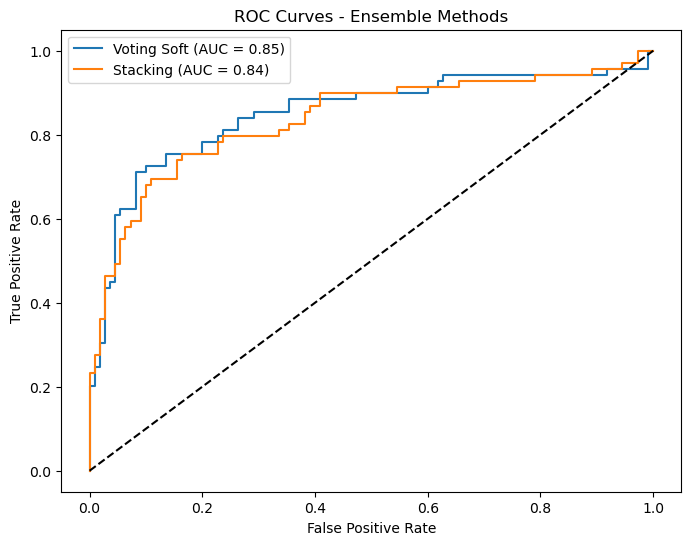

In [21]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    if results[name]["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC = {results[name]['ROC-AUC']:.2f})"
        )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Ensemble Methods")
plt.legend()
plt.show()

### Ensemble Methods

We tested ensemble approaches:

- **Voting Classifier (Hard & Soft)**: Combined Logistic Regression, Random Forest, and Gradient Boosting.
- **Stacking Classifier**: Used Random Forest, Gradient Boosting, and Decision Tree as base learners, with Logistic Regression as meta-learner.

**Findings:**
- Soft Voting improved ROC-AUC compared to individual models.
- Stacking yielded the strongest performance, leveraging complementary strengths of base learners.
- Ensembles reduce variance and improve robustness.

**Conclusion:**  
Ensemble methods outperform single models, with stacking providing the best balance of accuracy and generalization.
